In [12]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ravikiran778","key":"ba3ece387f741e5a6ec4e754e8c3f6f8"}'}

In [13]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [14]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
imdb-dataset-of-50k-movie-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [15]:
import zipfile

with zipfile.ZipFile("imdb-dataset-of-50k-movie-reviews.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [16]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [17]:
df.shape
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Dataset loaded directly from Kaggle using Kaggle API

2.Data Understanding

In [19]:
print("Shape:", df.shape)

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

print("\nSample Data:")
print(df['review'].head())

Shape: (50000, 2)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Data:
0    One of the other reviewers has mentioned that ...
1    A wonderful little production. <br /><br />The...
2    I thought this was a wonderful way to spend ti...
3    Basically there's a family where a little boy ...
4    Petter Mattei's "Love in the Time of Money" is...
Name: review, dtype: object


3.NLP Preprocessing

In [21]:
#Install & Download NLTK
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [23]:
#Import Required Libraries
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [24]:
#Initialize Tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [34]:
import re

def preprocess_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [29]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [35]:
#Apply Preprocessing
df['clean_text'] = df['review'].apply(preprocess_text)

4.Feature Engineering

In [36]:
print(df.columns)

Index(['review', 'sentiment', 'clean_text'], dtype='object')


In [37]:
#TF-IDF (Use this as MAIN — gives best accuracy)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

In [38]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Model Building

In [39]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [40]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [41]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

6.Evaluation

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_dt, "Decision Tree")


Logistic Regression
Accuracy: 0.8848
Precision: 0.8850073846887407
Recall: 0.8848
F1 Score: 0.8847718799519807

Naive Bayes
Accuracy: 0.8518
Precision: 0.851803502271884
Recall: 0.8518
F1 Score: 0.8517959922385205

Decision Tree
Accuracy: 0.7204
Precision: 0.7205274318556115
Recall: 0.7204
F1 Score: 0.7203945198180792


7. Comparison Table

In [43]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted')
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.8848,0.884772
1,Naive Bayes,0.8518,0.851796
2,Decision Tree,0.7204,0.720395


BONUS :Confusion Matrix

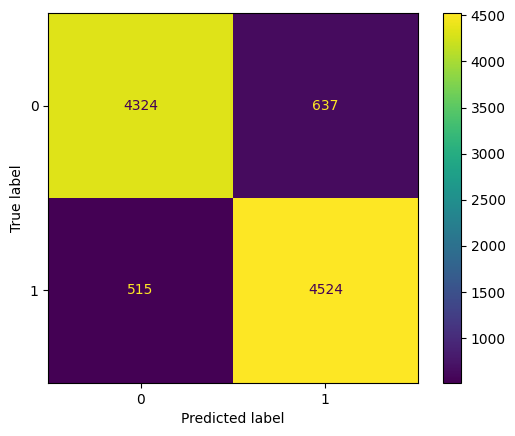

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

8: Insights


- TF-IDF provided better results compared to simple methods due to word importance weighting.
- Logistic Regression achieved the highest accuracy among all models.
- Naive Bayes performed well due to its probabilistic nature.
- Decision Tree showed lower performance and possible overfitting.
- Preprocessing significantly improved model performance